# 🏭 Custom Data Generator & Visualization
Notebook ini bertugas untuk membaca data nyata Anda (dari file `custom_data_payload.json`), memvisualisasikannya di atas peta 2D, lalu menormalisasi dan mengemasnya menjadi format `.pkl` agar bisa dibaca oleh Model RL HCVRPTW.

In [6]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Tambahkan path root agar bisa import utils
import sys
sys.path.append(os.path.abspath('.'))
from utils.data_utils import save_dataset

## 1. Membaca Data JSON
Pastikan Anda sudah mengisi titik kordinat Depot dan Customer di dalam file `data_generator/custom/custom_data_payload.json`.

In [7]:
json_path = 'data_generator/custom/custom_data_payload.json'

if not os.path.exists(json_path):
    print(f"File tidak ditemukan di: {json_path}")
else:
    with open(json_path, 'r') as f:
        payload = json.load(f)
        
    raw_depot_coords = payload['raw_depot_coords']
    raw_customer_coords = payload['raw_customer_coords']
    customer_demands = payload['customer_demands']
    tw_start = payload['time_window_default']['start_hour']
    tw_end = payload['time_window_default']['end_hour']
    
    num_customers = len(raw_customer_coords)
    
    print(f"Berhasil memuat data!")
    print(f"Lokasi Depot: {raw_depot_coords}")
    print(f"Jumlah Customer: {num_customers}")

Berhasil memuat data!
Lokasi Depot: [-6.372373, 106.752684]
Jumlah Customer: 37


## 🗺️ 2. Visualisasi Peta Titik Customer
Mari kita lihat sebaran kordinat (Latitude/Longitude) depot dan para pelanggan sebelum kita olah lebih lanjut.

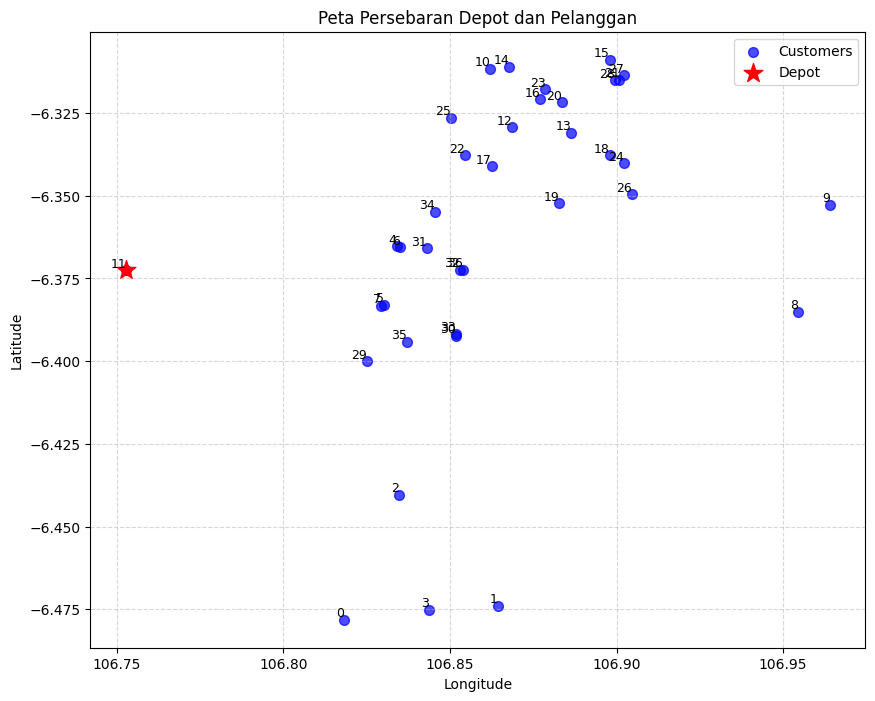

In [8]:
# Pisahkan X (Latitude) dan Y (Longitude)
depot_x, depot_y = raw_depot_coords[0], raw_depot_coords[1]
cust_x = [c[0] for c in raw_customer_coords]
cust_y = [c[1] for c in raw_customer_coords]

plt.figure(figsize=(10, 8))

# Plot Customers (Warna Biru)
plt.scatter(cust_y, cust_x, c='blue', s=50, label='Customers', alpha=0.7)

# Plot Depot (Warna Merah Bintang)
plt.scatter(depot_y, depot_x, c='red', s=200, marker='*', label='Depot')

# Tambahkan label index untuk customer
for i, (x, y) in enumerate(raw_customer_coords):
    plt.text(y, x, f'{i}', fontsize=9, ha='right', va='bottom')

plt.title('Peta Persebaran Depot dan Pelanggan')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 📏 3. Normalisasi Koordinat (Min-Max)
Model Machine Learning / RL biasanya hanya bekerja optimal jika input koordinat berada di rentang `[0, 1]`. Jika kita memberikan angka `-6.xxx`, performanya akan hancur.

In [9]:
all_coords = np.array([raw_depot_coords] + raw_customer_coords)
min_val = np.min(all_coords, axis=0)
max_val = np.max(all_coords, axis=0)
range_val = max_val - min_val
range_val[range_val == 0] = 1e-5 # Menghindari error pembagian nol

# Formula Min-Max Scaling
norm_coords = (all_coords - min_val) / range_val

depot_coords = norm_coords[0].tolist()
customer_coords = norm_coords[1:].tolist()

print(f"[SEBELUM] Kordinat Depot Asli: {raw_depot_coords}")
print(f"[SESUDAH] Kordinat Depot Normalisasi: {depot_coords}")

[SEBELUM] Kordinat Depot Asli: [-6.372373, 106.752684]
[SESUDAH] Kordinat Depot Normalisasi: [0.6249411319425311, 0.0]


## 📊 3.5. Visualisasi Peta Setelah Normalisasi
Sama seperti peta sebelumnya, namun kali ini sumbu X dan Y telah ditekan secara proporsional ke dalam rentang [0, 1] sesuai dengan batasan model.

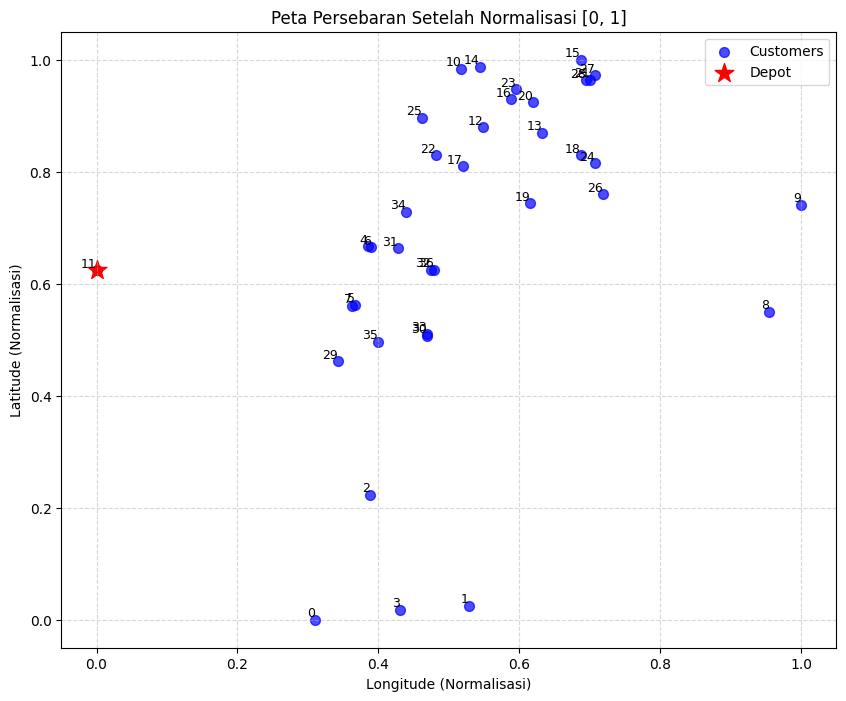

In [10]:
# Pisahkan X dan Y dari koordinat yang sudah dinormalisasi
n_depot_x, n_depot_y = depot_coords[0], depot_coords[1]
n_cust_x = [c[0] for c in customer_coords]
n_cust_y = [c[1] for c in customer_coords]

plt.figure(figsize=(10, 8))

# Plot Customers (Warna Biru)
plt.scatter(n_cust_y, n_cust_x, c='blue', s=50, label='Customers', alpha=0.7)

# Plot Depot (Warna Merah Bintang)
plt.scatter(n_depot_y, n_depot_x, c='red', s=200, marker='*', label='Depot')

# Tambahkan label index untuk customer
for i, (x, y) in enumerate(customer_coords):
    plt.text(y, x, f'{i}', fontsize=9, ha='right', va='bottom')

plt.title('Peta Persebaran Setelah Normalisasi [0, 1]')
plt.xlabel('Longitude (Normalisasi)')
plt.ylabel('Latitude (Normalisasi)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 📦 4. Mengemas & Menyimpan Data (Export to .pkl)
Terakhir, kita menyatukan data koordinat, demand, kapasitas kendaraan, dan matrix time-windows menjadi satu *Instance*.

In [11]:
# Konfigurasi Kapasitas Kendaraan (Default: 3 Truk Heterogen)
veh_num = 3
if veh_num == 3:
    vehicle_capacities = [6.2, 3.8, 2.2]
elif veh_num == 5:
    vehicle_capacities = [20.0, 25.0, 30.0, 35.0, 40.0]

# Membuat Matriks Time Windows (1 = Buka, 0 = Tutup)
time_windows = np.zeros((num_customers, 24))
for i in range(num_customers):
    time_windows[i, tw_start:tw_end] = 1

# Satukan semua elemen
instance = (
    depot_coords,
    customer_coords,
    customer_demands,
    vehicle_capacities,
    time_windows.tolist()
)

# Masukkan ke dalam dataset list (agar compatible dengan sistem evaluate.py)
dataset = [instance]

# Simpan ke folder data
save_path = 'data/hcvrp/custom_data_tw.pkl'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
save_dataset(dataset, save_path)

print(f"\u2705 Dataset berhasil dikemas dan disimpan di: {save_path}")

✅ Dataset berhasil dikemas dan disimpan di: data/hcvrp/custom_data_tw.pkl
